# 03. 전략 비교 대시보드

5개 전략의 성과 비교 + 기술적 지표 오버레이 + 파라미터 민감도 분석

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [2]:
import pandas as pd
from smart_stock.data import fetch_stock_cached
from smart_stock.strategies import (
    SMAcrossoverStrategy,
    RSIStrategy,
    MACDStrategy,
    BollingerBandStrategy,
    CompositeStrategy,
)
from smart_stock.backtesting import BacktestEngine, run_and_track
from smart_stock.tracking.logger import SignalLogger
from smart_stock.analysis import sma, rsi, bollinger_bands

## 1. 파라미터 설정

In [3]:
TICKER = "005930"       # 삼성전자
START = "2023-01-01"
END = "2024-12-31"
INITIAL_CAPITAL = 1_000_000

## 2. 데이터 로드

In [4]:
df = fetch_stock_cached(TICKER, start=START, end=END)
print(f"기간: {df.index[0].date()} ~ {df.index[-1].date()}, {len(df)}행")
df.head()

기간: 2023-01-02 ~ 2024-12-30, 489행


,Open,High,Low,Close,Volume
Date,,,,,
2023-01-02,55500,56100,55200,55500,10031448
2023-01-03,55400,56000,54500,55400,13547030
2023-01-04,55700,58000,55600,57800,20188071
2023-01-05,58200,58800,57600,58200,15682826
2023-01-06,58300,59400,57900,59000,17334989


## 3. 5개 전략 초기화

In [5]:
sma_st = SMAcrossoverStrategy(short_window=5, long_window=20)
rsi_st = RSIStrategy(period=14)
macd_st = MACDStrategy()
bb_st = BollingerBandStrategy()
composite_st = CompositeStrategy(strategies=[(sma_st, 0.5), (rsi_st, 0.5)])

strategies = {
    "SMA(5,20)": sma_st,
    "RSI(14)": rsi_st,
    "MACD": macd_st,
    "Bollinger(20,2)": bb_st,
    "Composite(SMA+RSI)": composite_st,
}

print(f"초기화된 전략: {list(strategies.keys())}")

초기화된 전략: ['SMA(5,20)', 'RSI(14)', 'MACD', 'Bollinger(20,2)', 'Composite(SMA+RSI)']


## 4. 전략별 백테스트 + 신호 기록

In [6]:
# 임시 logger (기본 경로 사용)
logger = SignalLogger()
logger.clear()  # 이전 기록 초기화

results = {}
for name, strategy in strategies.items():
    engine = BacktestEngine(initial_capital=INITIAL_CAPITAL)
    result = run_and_track(df, strategy, ticker=TICKER, engine=engine, logger=logger)
    results[name] = result
    print(f"[{name}] 수익률: {result.total_return:.2f}%, MDD: {result.mdd:.2f}%, 샤프: {result.sharpe_ratio:.2f}, 승률: {result.win_rate:.1f}%, 거래: {result.trade_count}회")

[SMA(5,20)] 수익률: -11.27%, MDD: -21.41%, 샤프: -0.33, 승률: 35.3%, 거래: 17회
[RSI(14)] 수익률: 4.23%, MDD: -10.20%, 샤프: 0.27, 승률: 57.1%, 거래: 7회
[MACD] 수익률: -16.00%, MDD: -33.91%, 샤프: -0.42, 승률: 40.0%, 거래: 20회
[Bollinger(20,2)] 수익률: 3.09%, MDD: -14.14%, 샤프: 0.22, 승률: 87.5%, 거래: 8회
[Composite(SMA+RSI)] 수익률: -7.52%, MDD: -21.48%, 샤프: -0.14, 승률: 41.7%, 거래: 24회


## 5. 성과 비교 테이블

In [7]:
summary = pd.DataFrame({
    name: {
        "총수익률(%)": round(r.total_return, 2),
        "MDD(%)": round(r.mdd, 2),
        "샤프지수": round(r.sharpe_ratio, 2),
        "승률(%)": round(r.win_rate, 1),
        "거래횟수": r.trade_count,
    }
    for name, r in results.items()
}).T

display(summary)

,총수익률(%),MDD(%),샤프지수,승률(%),거래횟수
"SMA(5,20)",-11.27,-21.41,-0.33,35.3,17.0
RSI(14),4.23,-10.20,0.27,57.1,7.0
MACD,-16.00,-33.91,-0.42,40.0,20.0
"Bollinger(20,2)",3.09,-14.14,0.22,87.5,8.0
Composite(SMA+RSI),-7.52,-21.48,-0.14,41.7,24.0


## 6. 시각화: 포트폴리오 가치 곡선

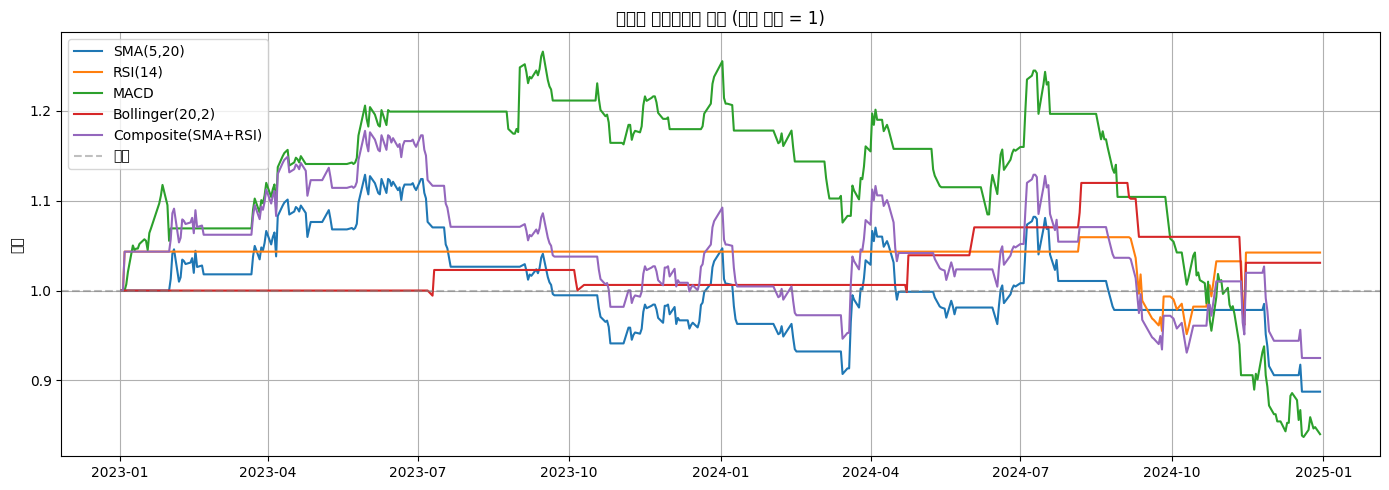

In [8]:
fig, ax = plt.subplots()
for name, result in results.items():
    ax.plot(result.portfolio.index, result.portfolio / INITIAL_CAPITAL, label=name)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="원금")
ax.set_title("전략별 포트폴리오 가치 (초기 자본 = 1)")
ax.set_ylabel("배율")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 7. 시각화: 드로우다운 비교

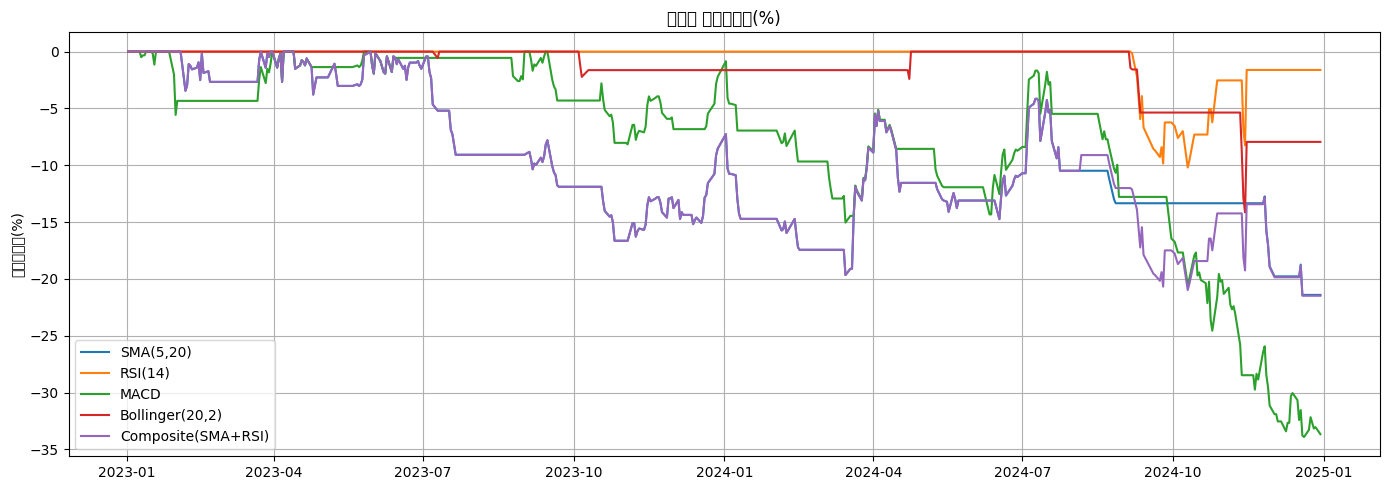

In [9]:
fig, ax = plt.subplots()
for name, result in results.items():
    dd = result.portfolio / result.portfolio.cummax() - 1
    ax.plot(dd.index, dd.values * 100, label=name)
ax.set_title("전략별 드로우다운(%)")
ax.set_ylabel("드로우다운(%)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 8. 기술적 지표: SMA(20, 60) 오버레이

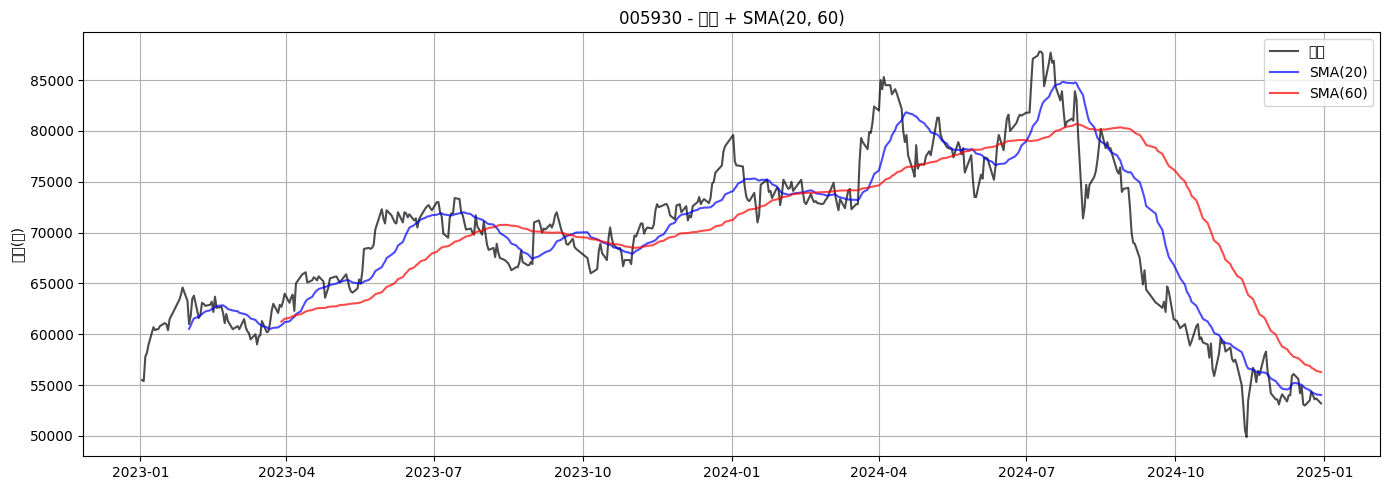

In [10]:
sma20 = sma(df["Close"], 20)
sma60 = sma(df["Close"], 60)

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], label="종가", color="black", alpha=0.7)
ax.plot(sma20.index, sma20.values, label="SMA(20)", color="blue", alpha=0.7)
ax.plot(sma60.index, sma60.values, label="SMA(60)", color="red", alpha=0.7)
ax.set_title(f"{TICKER} - 종가 + SMA(20, 60)")
ax.set_ylabel("가격(원)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. 기술적 지표: RSI(14) 서브플롯

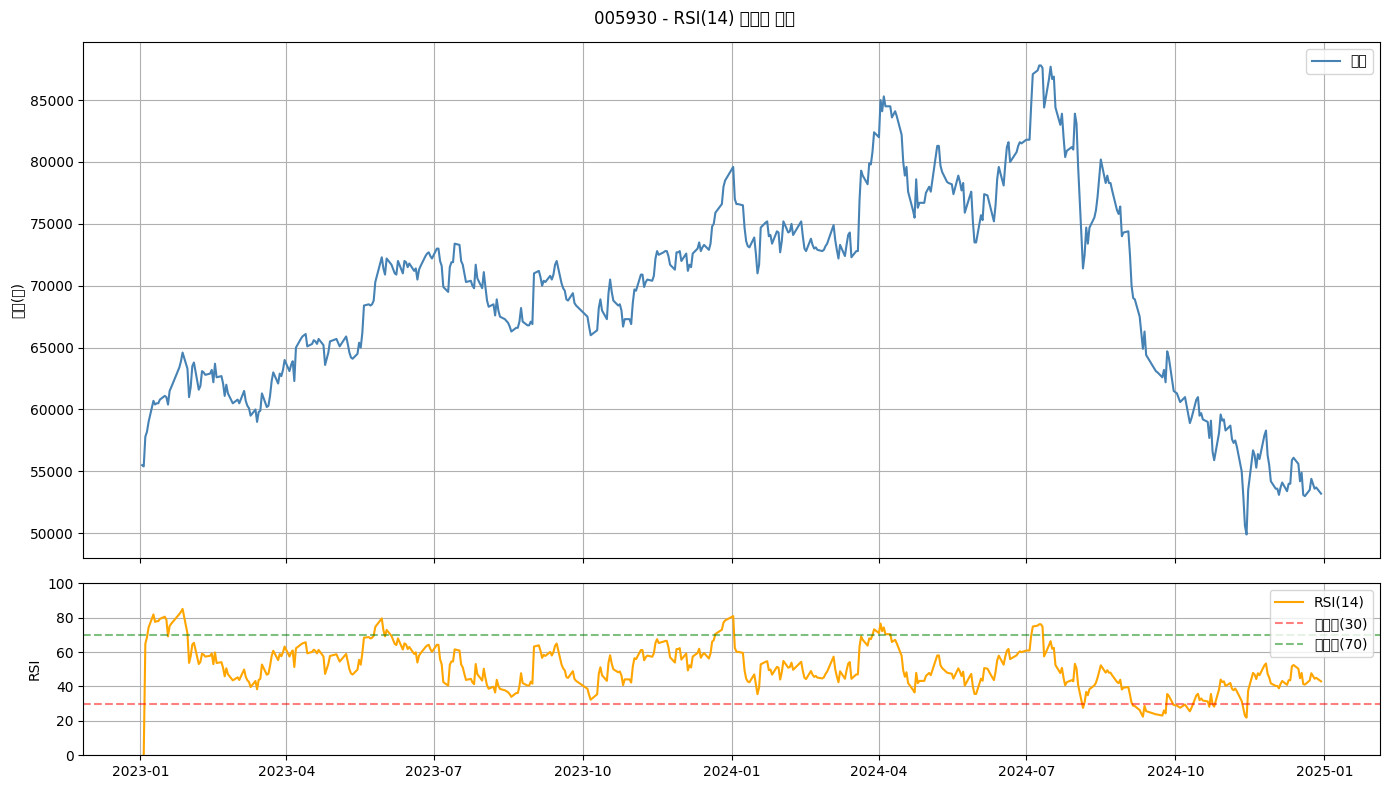

In [11]:
rsi_values = rsi(df["Close"], 14)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 8), gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(df.index, df["Close"], label="종가", color="steelblue")
ax1.set_ylabel("가격(원)")
ax1.legend()
ax1.grid(True)

ax2.plot(rsi_values.index, rsi_values.values, label="RSI(14)", color="orange")
ax2.axhline(30, color="red", linestyle="--", alpha=0.5, label="과매도(30)")
ax2.axhline(70, color="green", linestyle="--", alpha=0.5, label="과매수(70)")
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True)

fig.suptitle(f"{TICKER} - RSI(14) 기술적 지표")
plt.tight_layout()
plt.show()

## 10. 기술적 지표: 볼린저 밴드 오버레이

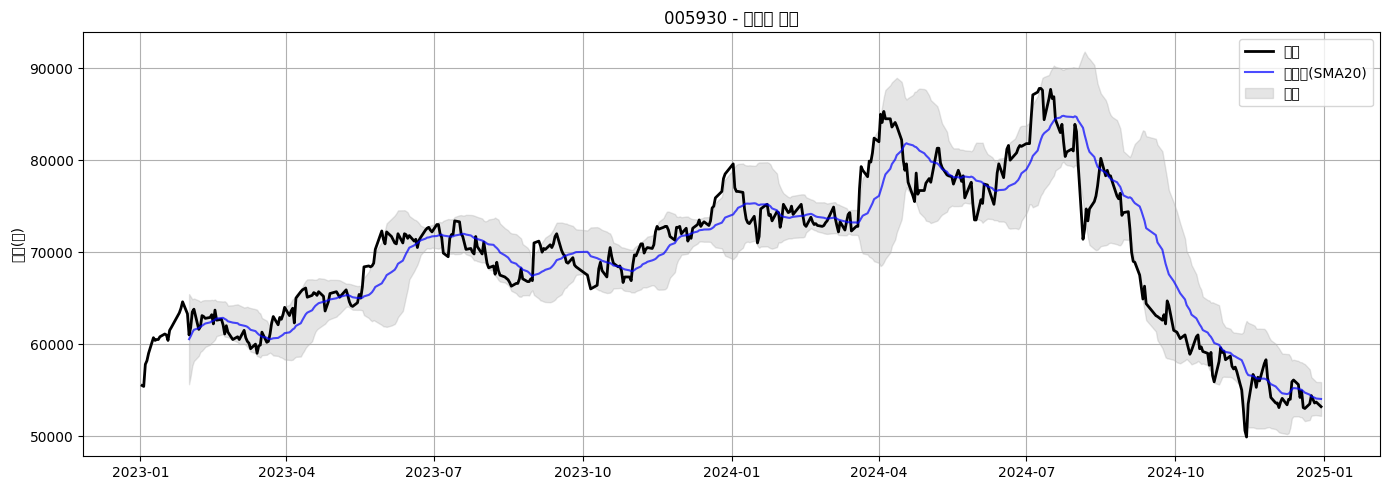

In [12]:
bb = bollinger_bands(df["Close"])

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], label="종가", color="black", linewidth=2)
ax.plot(bb.index, bb["middle"], label="중간선(SMA20)", color="blue", alpha=0.7)
ax.fill_between(bb.index, bb["lower"], bb["upper"], alpha=0.2, color="gray", label="밴드")
ax.set_title(f"{TICKER} - 볼린저 밴드")
ax.set_ylabel("가격(원)")
ax.legend()
plt.tight_layout()
plt.show()

## 11. 파라미터 스캔: SMA window 조합 민감도

In [13]:
short_windows = [5, 10, 20]
long_windows = [20, 50, 60]

scan_results = []
for short_w in short_windows:
    for long_w in long_windows:
        if short_w < long_w:
            strategy = SMAcrossoverStrategy(short_window=short_w, long_window=long_w)
            engine = BacktestEngine(initial_capital=INITIAL_CAPITAL)
            result = engine.run(df, strategy)
            scan_results.append({
                "Short": short_w,
                "Long": long_w,
                "수익률(%)": round(result.total_return, 2),
                "MDD(%)": round(result.mdd, 2),
                "샤프지수": round(result.sharpe_ratio, 2),
                "승률(%)": round(result.win_rate, 1),
            })

scan_df = pd.DataFrame(scan_results)
display(scan_df)

,Short,Long,수익률(%),MDD(%),샤프지수,승률(%)
0,5,20,-11.27,-21.41,-0.33,35.3
1,5,50,-16.36,-29.54,-0.47,22.2
2,5,60,-12.97,-26.12,-0.32,25.0
3,10,20,0.84,-20.11,0.10,35.3
4,10,50,-7.38,-22.00,-0.15,25.0
5,10,60,-3.98,-20.51,-0.03,40.0
6,20,50,3.01,-19.78,0.18,50.0
7,20,60,-5.00,-24.56,-0.06,40.0


## 12. CompositeStrategy 가중치 민감도 분석

In [14]:
weight_configs = [(0.3, 0.7), (0.5, 0.5), (0.7, 0.3)]
weight_results = []

for sma_weight, rsi_weight in weight_configs:
    sma_st_temp = SMAcrossoverStrategy(short_window=5, long_window=20)
    rsi_st_temp = RSIStrategy(period=14)
    composite_temp = CompositeStrategy(
        strategies=[(sma_st_temp, sma_weight), (rsi_st_temp, rsi_weight)]
    )
    engine = BacktestEngine(initial_capital=INITIAL_CAPITAL)
    result = engine.run(df, composite_temp)
    weight_results.append({
        "SMA 가중치": sma_weight,
        "RSI 가중치": rsi_weight,
        "수익률(%)": round(result.total_return, 2),
        "MDD(%)": round(result.mdd, 2),
        "샤프지수": round(result.sharpe_ratio, 2),
        "승률(%)": round(result.win_rate, 1),
    })

weight_df = pd.DataFrame(weight_results)
display(weight_df)

,SMA 가중치,RSI 가중치,수익률(%),MDD(%),샤프지수,승률(%)
0,0.3,0.7,4.23,-10.20,0.27,57.1
1,0.5,0.5,-7.52,-21.48,-0.14,41.7
2,0.7,0.3,-11.27,-21.41,-0.33,35.3


## 13. 신호 시각화: 최고 샤프비율 전략의 매수/매도

최고 샤프지수 전략: RSI(14) (0.27)
해당 전략 시그널 수: 14


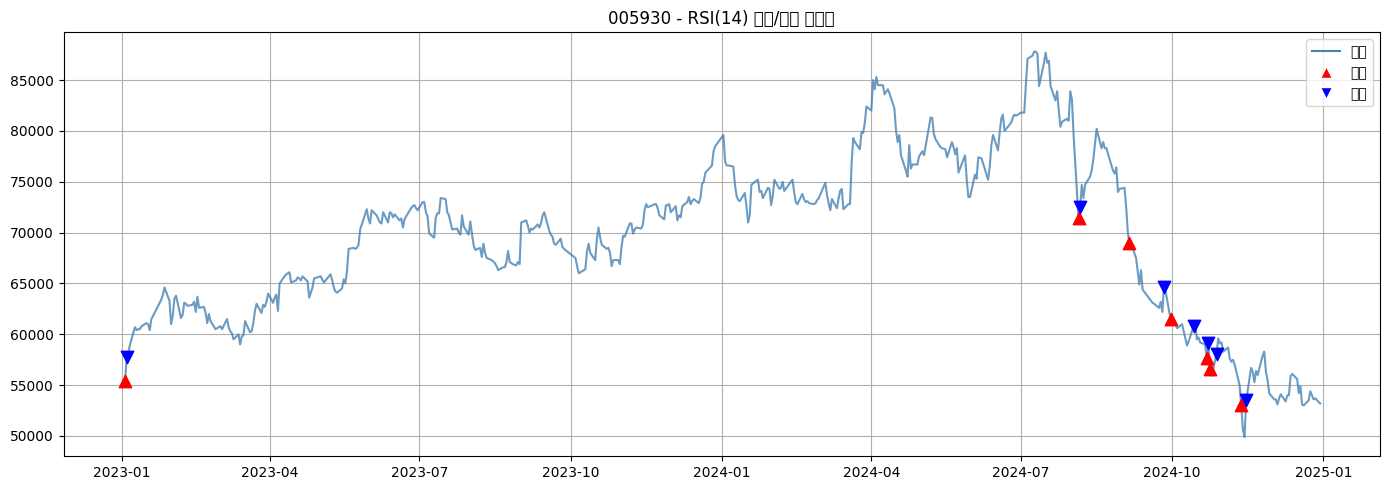

In [15]:
best_name = max(results, key=lambda n: results[n].sharpe_ratio)
print(f"최고 샤프지수 전략: {best_name} ({results[best_name].sharpe_ratio:.2f})")

signals_df = logger.load()
best_signals = signals_df[signals_df["strategy_name"] == type(strategies[best_name]).__name__]
print(f"해당 전략 시그널 수: {len(best_signals)}")

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="steelblue", alpha=0.8, label="종가")

for _, row in best_signals.iterrows():
    if int(row["signal"]) == 1:
        ax.scatter(row["signal_date"], row["price"], marker="^", color="red", s=80, zorder=5)
    elif int(row["signal"]) == -1:
        ax.scatter(row["signal_date"], row["price"], marker="v", color="blue", s=80, zorder=5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue", label="종가"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="red", markersize=8, label="매수"),
    Line2D([0], [0], marker="v", color="w", markerfacecolor="blue", markersize=8, label="매도"),
]
ax.legend(handles=legend_elements)
ax.set_title(f"{TICKER} - {best_name} 매수/매도 시그널")
plt.tight_layout()
plt.show()

## 14. 분석 요약

### 전략별 강·약점

| 전략 | 강점 | 약점 |
|------|------|------|
| **SMA(5,20)** | 빠른 반응 | 변동성 시장에서 손실 |
| **RSI(14)** | 과매수/매도 신호 | 추세 추종 약함 |
| **MACD** | 추세 확인 | 지연 신호 |
| **Bollinger** | 극값 거래 | 박스권에서 보합신호 |
| **Composite** | 다중 신호 앙상블 | 매개변수 튜닝 필요 |

### 실무 활용 가이드

1. **파라미터 스캔** 결과를 통해 최적 윈도우 크기 확인
2. **CompositeStrategy 가중치**를 시장 환경에 따라 조정
3. **드로우다운**이 작은 전략을 위험 관리 우선 시
4. **승률**과 **샤프지수** 균형으로 전략 선택
5. 실거래 전 **역테스트(Out-of-sample)** 검증 필수